## **AI - PIPELINE FOR MACHINE LEARNING MODELS**

In [ ]:
# =====================================================================
# 1. DATA IMPORTATION
# =====================================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

In [3]:
# Load the dataset
df = pd.read_csv('Heart.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (303, 15)


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD,HD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No,0
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes,1
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes,1
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No,0
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No,0


In [5]:
# =====================================================================
# 2. DATA CLEAN AND PREPROCESSING
# =====================================================================

In [4]:
# Replace 'NA' strings with actual NaN values
df.replace('NA', np.nan, inplace=True)

# The dataset has two target-like columns: 'AHD' (Yes/No) and 'hd' (1/0). 
# We will use 'hd' as our binary target and drop 'AHD' to prevent data leakage.
df.drop(columns=['AHD'], inplace=True)

In [6]:
# Check missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Age          0
Sex          0
ChestPain    0
RestBP       0
Chol         0
Fbs          0
RestECG      0
MaxHR        0
ExAng        0
Oldpeak      0
Slope        0
Ca           4
Thal         2
HD           0
dtype: int64


In [8]:
# Separate features (X) and target (y)
X = df.drop(columns=['HD'])
y = df['HD']

# Define categorical and numerical columns
cat_cols = ['ChestPain', 'Thal']
num_cols = [col for col in X.columns if col not in cat_cols]

In [9]:
# =====================================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# =====================================================================

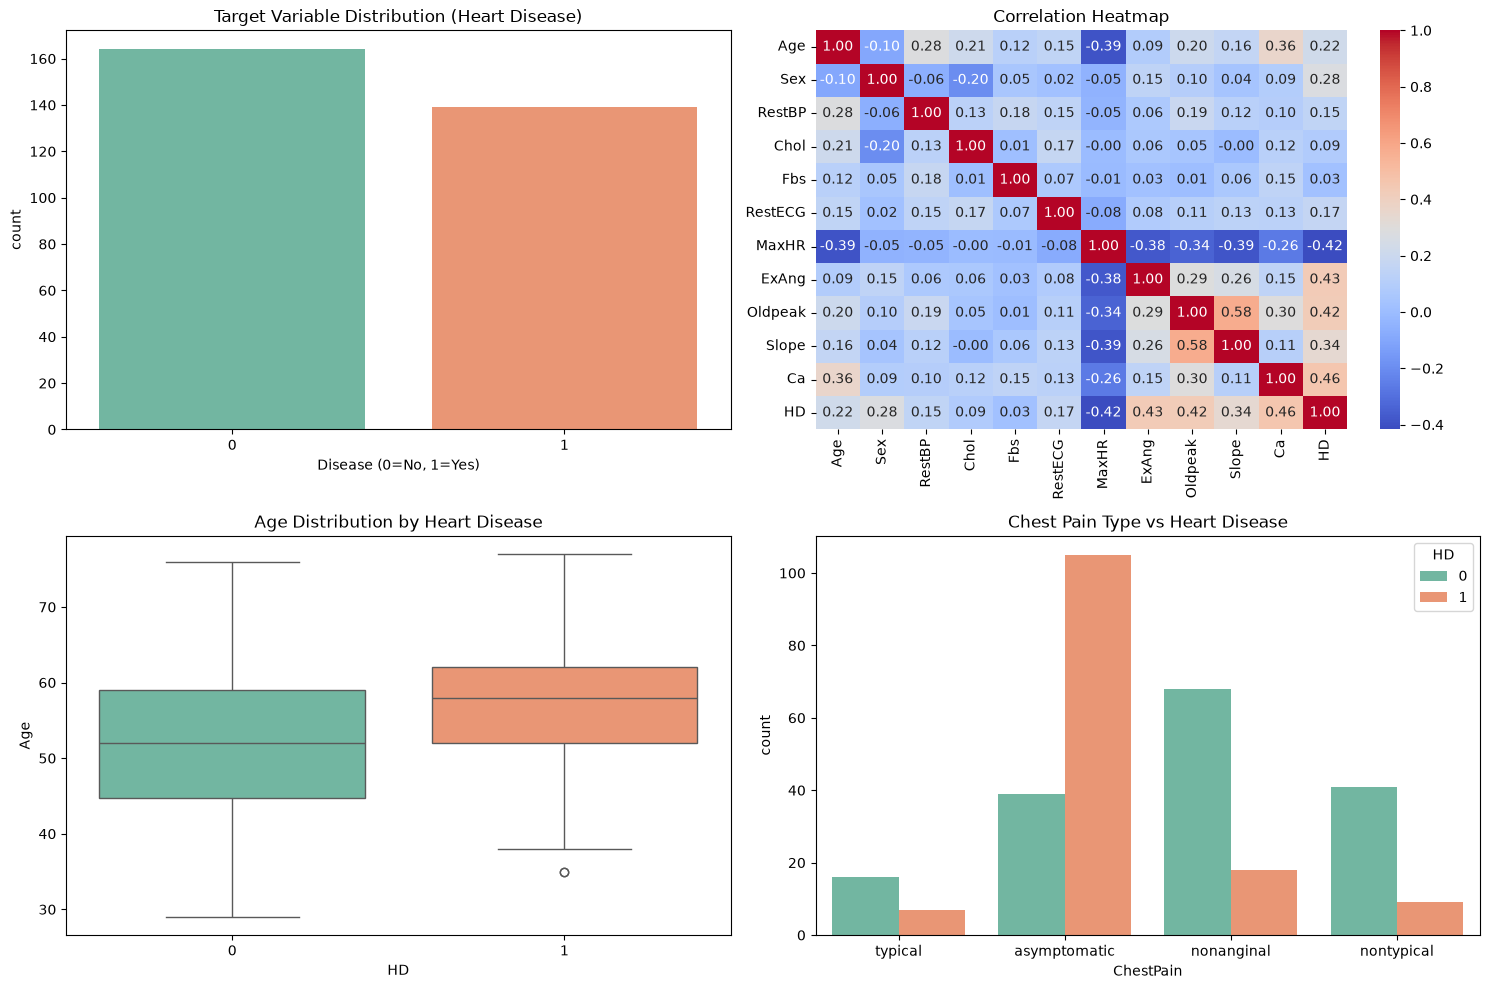

In [15]:
plt.figure(figsize=(15, 10))

# Target Distribution
plt.subplot(2, 2, 1)
sns.countplot(x=y, palette='Set2')
plt.title('Target Variable Distribution (Heart Disease)')
plt.xlabel('Disease (0=No, 1=Yes)')

# Correlation Heatmap
plt.subplot(2, 2, 2)
numeric_df = df[num_cols + ['HD']].apply(pd.to_numeric, errors='coerce')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
# Age vs Heart Disease
plt.subplot(2, 2, 3)
sns.boxplot(x=y, y='Age', data=df, palette='Set2')
plt.title('Age Distribution by Heart Disease')

# Chest Pain vs Heart Disease
plt.subplot(2, 2, 4)
sns.countplot(x='ChestPain', hue='HD', data=df, palette='Set2')
plt.title('Chest Pain Type vs Heart Disease')

plt.tight_layout()
plt.show()


In [17]:
# =====================================================================
# 4. DATA PARTITIONING
# =====================================================================

In [16]:
from sklearn.model_selection import train_test_split

# Stratify ensures the same proportion of disease/no-disease in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTraining set size: {X_train.shape[0]}, Testing set size: {X_test.shape[0]}")


Training set size: 242, Testing set size: 61


In [ ]:
# =====================================================================
# 5. DATA TRANSFORMATION (Pipeline & ColumnTransformer)
# =====================================================================

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical pipeline: Impute missing values with median, then scale
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [19]:
# Categorical pipeline: Impute missing values with mode, then One-Hot Encode
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [20]:
# Combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

In [21]:
# =====================================================================
# 6. MODEL TRAINING
# =====================================================================

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42, use_label_encoder=False)
}

# Create and train pipelines
model_pipelines = {}
for name, model in models.items():
    model_pipelines[name] = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    model_pipelines[name].fit(X_train, y_train)

In [23]:
# =====================================================================
# 7. MODEL EVALUATION
# =====================================================================

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

results = {}

print("\n" + "="*50)
print("MODEL EVALUATION METRICS")
print("="*50)

for name, pipeline in model_pipelines.items():
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }

results_df = pd.DataFrame(results).T
print(results_df)


MODEL EVALUATION METRICS
                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Logistic Regression  0.901639   0.866667  0.928571  0.896552  0.956710
KNN                  0.901639   0.843750  0.964286  0.900000  0.964827
SVM                  0.868852   0.794118  0.964286  0.870968  0.961039
Random Forest        0.885246   0.818182  0.964286  0.885246  0.934524
Decision Tree        0.721311   0.677419  0.750000  0.711864  0.723485
XGBoost              0.852459   0.787879  0.928571  0.852459  0.924242


In [25]:
# =====================================================================
# 8. SELECTION OF THE BEST MODEL
# =====================================================================

In [26]:
# We select the best model based on the F1-Score (balances Precision and Recall)
best_model_name = results_df['F1-Score'].idxmax()
best_model_pipeline = model_pipelines[best_model_name]

print(f"\n🏆 BEST MODEL SELECTED: {best_model_name}")
print("\nDetailed Classification Report for Best Model:")
print(classification_report(y_test, best_model_pipeline.predict(X_test)))


🏆 BEST MODEL SELECTED: KNN

Detailed Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.97      0.85      0.90        33
           1       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



In [27]:
# =====================================================================
# 9. CONCLUSION BASED ON THE BEST MODEL
# =====================================================================

In [28]:
print("\n" + "="*50)
print("CONCLUSION")
print("="*50)
best_f1 = results_df.loc[best_model_name, 'F1-Score']
best_auc = results_df.loc[best_model_name, 'ROC-AUC']

print(f"The {best_model_name} model emerged as the best performer with an F1-Score of {best_f1:.4f} and ROC-AUC of {best_auc:.4f}.")
print("This indicates a strong balance between identifying actual heart disease cases (Recall)")
print("and minimizing false alarms (Precision).")

# Feature Importance (if the best model is tree-based)
if best_model_name in ['Random Forest', 'XGBoost', 'Decision Tree']:
    # Extract feature names after One-Hot Encoding
    cat_encoder = best_model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
    cat_features = cat_encoder.get_feature_names_out(cat_cols)
    feature_names = num_cols + list(cat_features)
    
    importances = best_model_pipeline.named_steps['classifier'].feature_importances_
    feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)
    
    print("\nTop 5 Most Important Features:")
    print(feat_imp_df.head(5))


CONCLUSION
The KNN model emerged as the best performer with an F1-Score of 0.9000 and ROC-AUC of 0.9648.
This indicates a strong balance between identifying actual heart disease cases (Recall)
and minimizing false alarms (Precision).


In [29]:
# =====================================================================
# 10. DEPLOYMENT
# =====================================================================

In [30]:
# Save the best model to disk using joblib
model_filename = 'best_heart_disease_model.pkl'
joblib.dump(best_model_pipeline, model_filename)
print(f"\n✅ Best model successfully saved as '{model_filename}' for deployment.")



✅ Best model successfully saved as 'best_heart_disease_model.pkl' for deployment.
